In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import rankdata

In [2]:
DATA_FILES = [
    (1,  'ha-1sec-full-rl-v4.pqt'),
    (2,  'ha-2sec-full-rl-v4.pqt'),
    (3,  'ha-3sec-full-rl-v4.pqt'),
    (4,  'ha-4sec-full-rl-v4.pqt'),
    (8,  'ha-8sec-full-rl-v4.pqt'),
    (16, 'ha-16sec-full-rl-v4.pqt'),
]
OUT_DIR = 'e2_out'
L = 32
MIN_LEN = 4
MIN_RANGE_PTS = 0.5
TICK = 0.0625
POOL_CAP = 300_000
PAIR_CAP = 150_000
TEST_FRAC = 0.2
NUM_ROUNDS = 150
PARAMS = {
    'objective': 'binary',
    'learning_rate': 0.1,
    'num_leaves': 63,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': 7,
}

os.makedirs(OUT_DIR, exist_ok=True)
rng = np.random.default_rng(7)

In [5]:
def load_shapes(path):
    df = pd.read_parquet('../' + path, columns=['date', 'Close', 'jmaD1'])
    date = df['date'].to_numpy()
    close = df['Close'].to_numpy(np.float64)
    s = pd.Series(np.sign(df['jmaD1'].to_numpy())).replace(0.0, np.nan)
    s = s.groupby(date).ffill().groupby(date).bfill().to_numpy()
    m = len(df)
    new_day = np.empty(m, dtype=bool); new_day[0] = True
    new_day[1:] = date[1:] != date[:-1]
    flip = np.empty(m, dtype=bool); flip[0] = True
    flip[1:] = s[1:] != s[:-1]
    starts = np.flatnonzero(new_day | flip)
    ends = np.r_[starts[1:], m]
    lens = ends - starts
    keep = np.flatnonzero(lens >= MIN_LEN)
    if len(keep) > POOL_CAP:
        keep = rng.choice(keep, POOL_CAP, replace=False)
    xs = np.linspace(0.0, 1.0, L)
    shapes = np.empty((len(keep), L), np.float32)
    qs = np.empty(len(keep), np.float32)
    days = date[starts[keep]]
    ok = np.ones(len(keep), dtype=bool)
    for i, k in enumerate(keep):
        seg = close[starts[k]:ends[k]]
        lo = seg.min()
        r = seg.max() - lo
        if r < MIN_RANGE_PTS:
            ok[i] = False
            continue
        shapes[i] = np.interp(xs, np.linspace(0.0, 1.0, lens[k]), seg - lo) / r
        qs[i] = TICK / r
    return shapes[ok], qs[ok], days[ok]


def auc(y, p):
    r = rankdata(p)
    n1 = int(y.sum())
    n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n0)

In [7]:
frames = {}
for n, path in DATA_FILES:
    frames[n] = load_shapes(path)
    print(f"n={n:>2}s segments kept: {len(frames[n][0]):,}", flush=True)

n= 1s segments kept: 293,436
n= 2s segments kept: 296,821
n= 3s segments kept: 297,966
n= 4s segments kept: 298,675
n= 8s segments kept: 299,506
n=16s segments kept: 152,557


 1s vs  2s  n/class=150,000  AUC raw=0.5367  dith=0.5726
 1s vs  3s  n/class=150,000  AUC raw=0.5659  dith=0.6221
 1s vs  4s  n/class=150,000  AUC raw=0.5857  dith=0.6540
 1s vs  8s  n/class=150,000  AUC raw=0.6135  dith=0.7339
 1s vs 16s  n/class=150,000  AUC raw=0.6464  dith=0.7996
 2s vs  3s  n/class=150,000  AUC raw=0.5095  dith=0.5341
 2s vs  4s  n/class=150,000  AUC raw=0.5199  dith=0.5717
 2s vs  8s  n/class=150,000  AUC raw=0.5555  dith=0.6613
 2s vs 16s  n/class=150,000  AUC raw=0.5829  dith=0.7338
 3s vs  4s  n/class=150,000  AUC raw=0.5031  dith=0.5169
 3s vs  8s  n/class=150,000  AUC raw=0.5233  dith=0.6043
 3s vs 16s  n/class=150,000  AUC raw=0.5514  dith=0.6886
 4s vs  8s  n/class=150,000  AUC raw=0.5139  dith=0.5724
 4s vs 16s  n/class=150,000  AUC raw=0.5367  dith=0.6617
 8s vs 16s  n/class=150,000  AUC raw=0.5089  dith=0.5725


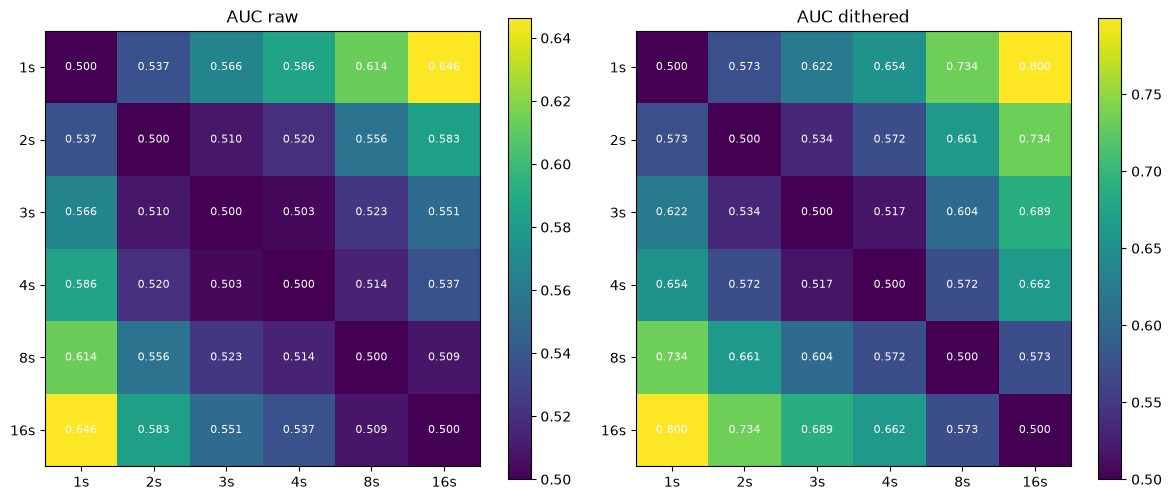

In [8]:
ns = sorted(frames)
K = len(ns)
A_raw = np.full((K, K), np.nan)
A_dit = np.full((K, K), np.nan)
rows = []
for i in range(K):
    for j in range(i + 1, K):
        sa, qa, da = frames[ns[i]]
        sb, qb, db = frames[ns[j]]
        take = min(len(sa), len(sb), PAIR_CAP)
        ia = rng.choice(len(sa), take, replace=False)
        ib = rng.choice(len(sb), take, replace=False)
        X = np.vstack([sa[ia], sb[ib]])
        q = np.concatenate([qa[ia], qb[ib]])[:, None]
        y = np.r_[np.zeros(take, np.int8), np.ones(take, np.int8)]
        day = np.concatenate([da[ia], db[ib]])
        ud = np.unique(day)
        te_days = rng.choice(ud, int(len(ud) * TEST_FRAC), replace=False)
        te = np.isin(day, te_days)
        tr = ~te
        out = {}
        for name, Xv in (('raw', X),
                         ('dith', X + (rng.uniform(-0.5, 0.5, X.shape) * q).astype(np.float32))):
            mdl = lgb.train(PARAMS, lgb.Dataset(Xv[tr], label=y[tr]), num_boost_round=NUM_ROUNDS)
            out[name] = auc(y[te], mdl.predict(Xv[te]))
        A_raw[i, j] = A_raw[j, i] = out['raw']
        A_dit[i, j] = A_dit[j, i] = out['dith']
        rows.append((ns[i], ns[j], take, out['raw'], out['dith']))
        print(f"{ns[i]:>2}s vs {ns[j]:>2}s  n/class={take:,}  "
              f"AUC raw={out['raw']:.4f}  dith={out['dith']:.4f}", flush=True)

res = pd.DataFrame(rows, columns=['n_a', 'n_b', 'per_class', 'auc_raw', 'auc_dith'])
res.to_csv(os.path.join(OUT_DIR, 'e2_pairs.csv'), index=False)
np.fill_diagonal(A_raw, 0.5)
np.fill_diagonal(A_dit, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, M, title in ((axes[0], A_raw, 'AUC raw'), (axes[1], A_dit, 'AUC dithered')):
    im = ax.imshow(M, vmin=0.5, vmax=max(0.55, float(np.nanmax(M))), cmap='viridis')
    ax.set_xticks(range(K), [f"{n}s" for n in ns])
    ax.set_yticks(range(K), [f"{n}s" for n in ns])
    ax.set_title(title)
    for a in range(K):
        for b in range(K):
            ax.text(b, a, f"{M[a, b]:.3f}", ha='center', va='center', color='w', fontsize=8)
    fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'auc_matrix.png'), dpi=130)
plt.show()